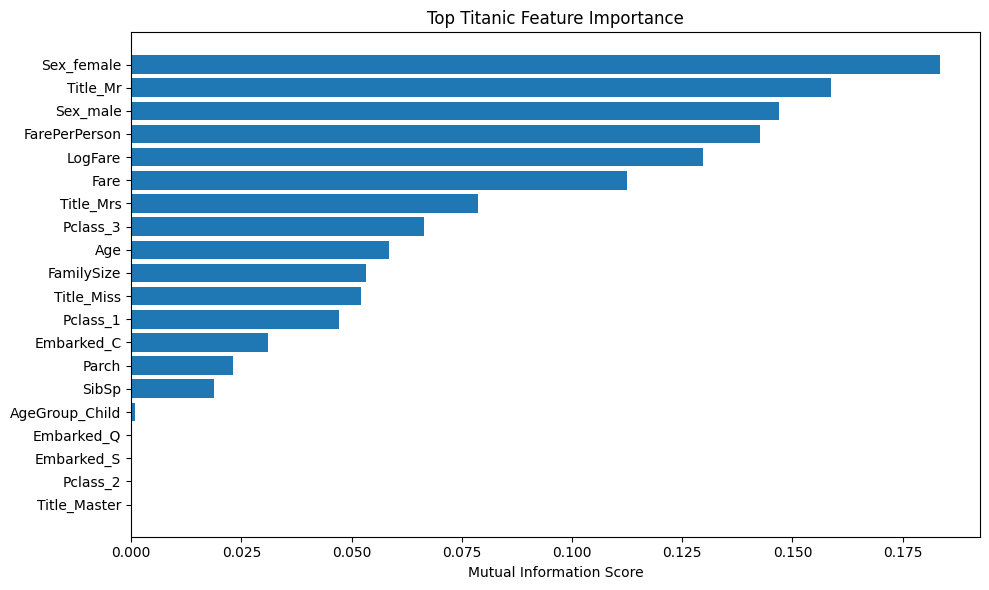

Feature selection completed


In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

from pathlib import Path

PROJECT_ROOT = Path.cwd()
# print("my path ", PROJECT_ROOT)
# # PROCESSED_DIR = PROJECT_ROOT / "src" / "data" / "processed"

# Load data
X_train = np.load(PROJECT_ROOT/"../data/processed/X_train.npy")
y_train = np.load(PROJECT_ROOT/"../data/processed/y_train.npy")

with open(PROJECT_ROOT/"../features/feature_list.json", "r") as f:
    feature_names = json.load(f)

# Mutual Information
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# Sort features
mi_features = sorted(
    zip(feature_names, mi_scores),
    key=lambda x: x[1],
    reverse=True
)

# Select top 20
TOP_K = 20
selected = mi_features[:TOP_K]

# Save selected features
with open(PROJECT_ROOT/"../features/selected_features.json", "w") as f:
    json.dump([f[0] for f in selected], f, indent=4)

# Plot
features = [f[0] for f in selected]
scores = [f[1] for f in selected]

plt.figure(figsize=(10, 6))
plt.barh(features, scores)
plt.gca().invert_yaxis()
plt.title("Top Titanic Feature Importance")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.savefig(PROJECT_ROOT/"../features/feature_importance.png")
plt.show()

print("Feature selection completed")
